In [2]:
import os

cache_root = "/scratch/gilbreth/abelde"

os.environ["HOME"]              = cache_root
os.environ["PIP_CACHE_DIR"]     = os.path.join(cache_root, ".cache", "pip")
os.environ["TORCH_HOME"]        = os.path.join(cache_root, ".cache", "torch")
os.environ["HF_HOME"]           = os.path.join(cache_root, ".cache", "huggingface")
os.environ["XDG_CACHE_HOME"]    = os.path.join(cache_root, ".cache")
os.environ["TMPDIR"]            = os.path.join(cache_root, "tmp")

os.makedirs(os.environ["PIP_CACHE_DIR"], exist_ok=True)
os.makedirs(os.environ["TORCH_HOME"], exist_ok=True)
os.makedirs(os.environ["HF_HOME"], exist_ok=True)
os.makedirs(os.environ["XDG_CACHE_HOME"], exist_ok=True)
os.makedirs(os.environ["TMPDIR"], exist_ok=True)

print("Cache directories set under:", cache_root)

Cache directories set under: /scratch/gilbreth/abelde


In [3]:
import os
import sys
import time

repo_root = "/scratch/gilbreth/abelde/Vision_Graphics/3DGS/gaussian-splatting"
data_path = "/scratch/gilbreth/abelde/Vision_Graphics/3DGS/datasets/garden"
output_dir = os.path.join(repo_root, "output/debug_garden")

if repo_root not in sys.path:
    sys.path.insert(0, repo_root)

print("Warming up torch. The first import can take around 1-2 minutes in this environment...")
t0 = time.time()
import torch
print(f"torch imported in {time.time() - t0:.1f}s")
print("torch version:", torch.__version__)
print("CUDA available:", torch.cuda.is_available())
if torch.cuda.is_available():
    print("GPU:", torch.cuda.get_device_name(0))

Warming up torch. The first import can take around 1-2 minutes in this environment...
torch imported in 115.8s
torch version: 2.1.2
CUDA available: True
GPU: NVIDIA A30


In [3]:
import importlib
import sys
from argparse import ArgumentParser

import train
importlib.reload(train)

from arguments import ModelParams, PipelineParams, OptimizationParams
from utils.general_utils import safe_state

sys.argv = [
    "train.py",
    "--source_path", data_path,
    "--model_path", output_dir,
    "--iterations", "30000",
    "--save_iterations", "7000", "30000",
    "--test_iterations", "7000", "30000",
    "--eval",
    "--disable_viewer",
]

parser = ArgumentParser(description="Training script parameters")
lp = ModelParams(parser)
op = OptimizationParams(parser)
pp = PipelineParams(parser)
parser.add_argument("--ip", type=str, default="127.0.0.1")
parser.add_argument("--port", type=int, default=6009)
parser.add_argument("--debug_from", type=int, default=-1)
parser.add_argument("--detect_anomaly", action="store_true", default=False)
parser.add_argument("--test_iterations", nargs="+", type=int, default=[7_000, 30_000])
parser.add_argument("--save_iterations", nargs="+", type=int, default=[7_000, 30_000])
parser.add_argument("--quiet", action="store_true")
parser.add_argument("--disable_viewer", action="store_true", default=False)
parser.add_argument("--checkpoint_iterations", nargs="+", type=int, default=[])
parser.add_argument("--start_checkpoint", type=str, default=None)

args = parser.parse_args(sys.argv[1:])
args.save_iterations.append(args.iterations)

print("Optimizing", args.model_path)


Optimizing /scratch/gilbreth/abelde/Vision_Graphics/3DGS/gaussian-splatting/output/debug_garden


In [4]:
import importlib
import sys
from argparse import ArgumentParser

import train
importlib.reload(train)

from arguments import ModelParams, PipelineParams, OptimizationParams
from utils.general_utils import safe_state

sys.argv = [
    "train.py",
    "--source_path", data_path,
    "--model_path", output_dir,
    "--iterations", "10",
    "--save_iterations", "10",
    "--test_iterations", "-1",
    "--resolution", "8",
    "--data_device", "cpu",
    "--max_train_cameras", "2",
    "--max_test_cameras", "1",
    "--densify_until_iter", "0",
    "--disable_viewer",
]

parser = ArgumentParser(description="Training script parameters")
lp = ModelParams(parser)
op = OptimizationParams(parser)
pp = PipelineParams(parser)
parser.add_argument("--ip", type=str, default="127.0.0.1")
parser.add_argument("--port", type=int, default=6009)
parser.add_argument("--debug_from", type=int, default=-1)
parser.add_argument("--detect_anomaly", action="store_true", default=False)
parser.add_argument("--test_iterations", nargs="+", type=int, default=[7_000, 30_000])
parser.add_argument("--save_iterations", nargs="+", type=int, default=[7_000, 30_000])
parser.add_argument("--quiet", action="store_true")
parser.add_argument("--disable_viewer", action="store_true", default=False)
parser.add_argument("--checkpoint_iterations", nargs="+", type=int, default=[])
parser.add_argument("--start_checkpoint", type=str, default=None)

args = parser.parse_args(sys.argv[1:])
args.save_iterations.append(args.iterations)

print("Optimizing", args.model_path)
print("Debug argv:")
print(" ".join(sys.argv))

Optimizing /scratch/gilbreth/abelde/Vision_Graphics/3DGS/gaussian-splatting/output/debug_garden
Debug argv:
train.py --source_path /scratch/gilbreth/abelde/Vision_Graphics/3DGS/datasets/garden --model_path /scratch/gilbreth/abelde/Vision_Graphics/3DGS/gaussian-splatting/output/debug_garden --iterations 10 --save_iterations 10 --test_iterations -1 --resolution 8 --data_device cpu --max_train_cameras 2 --max_test_cameras 1 --densify_until_iter 0 --disable_viewer


In [ ]:
safe_state(args.quiet)
torch.autograd.set_detect_anomaly(args.detect_anomaly)

print("Running minimal debug training...")
train.training(
    lp.extract(args),
    op.extract(args),
    pp.extract(args),
    args.test_iterations,
    args.save_iterations,
    args.checkpoint_iterations,
    args.start_checkpoint,
    args.debug_from,
)

print("Training completed successfully.")

Running minimal debug training... [03/04 10:34:22]
Output folder: /scratch/gilbreth/abelde/Vision_Graphics/3DGS/gaussian-splatting/output/debug_garden [03/04 10:34:58]
Reading camera 2/185

5903.58s - name 'array' is not defined
Traceback (most recent call last):
  File "/scratch/gilbreth/abelde/Vision_Graphics/3DGS/gaussian-splatting/gaussian_splatting_env/lib/python3.10/site-packages/debugpy/_vendored/pydevd/_pydevd_bundle/pydevd_vars.py", line 629, in change_attr_expression
    value = eval(expression, frame.f_globals, frame.f_locals)
  File "<string>", line 1, in <module>
NameError: name 'array' is not defined


Reading camera 185/185 [03/04 12:10:57]
Limiting training cameras to 2 of 185 for this run [03/04 12:13:54]
Limiting test cameras to 0 of 0 for this run [03/04 12:13:54]
Loading Training Cameras [03/04 12:14:00]
Loading Test Cameras [03/04 16:31:52]
Number of points at initialisation :  138766 [03/04 17:34:04]


Training progress:   0%|          | 0/10 [00:00<?, ?it/s]

In [6]:
# ──────────── Render trained model ────────────
import subprocess, sys

env_python = "/scratch/gilbreth/abelde/Vision_Graphics/3DGS/gaussian-splatting/gaussian_splatting_env/bin/python"
render_script = os.path.join(repo_root, "render.py")
model_path = "/scratch/gilbreth/abelde/Vision_Graphics/3DGS/gaussian-splatting/output/garden_production"

cmd = [
    env_python, render_script,
    "-m", model_path,
    "--iteration", "30000",
]

print("Running render.py ...")
result = subprocess.run(cmd, cwd=repo_root, capture_output=True, text=True)
print(result.stdout[-2000:] if len(result.stdout) > 2000 else result.stdout)
if result.returncode != 0:
    print("STDERR:", result.stderr[-2000:])
else:
    print("Rendering complete!")


KeyboardInterrupt: 

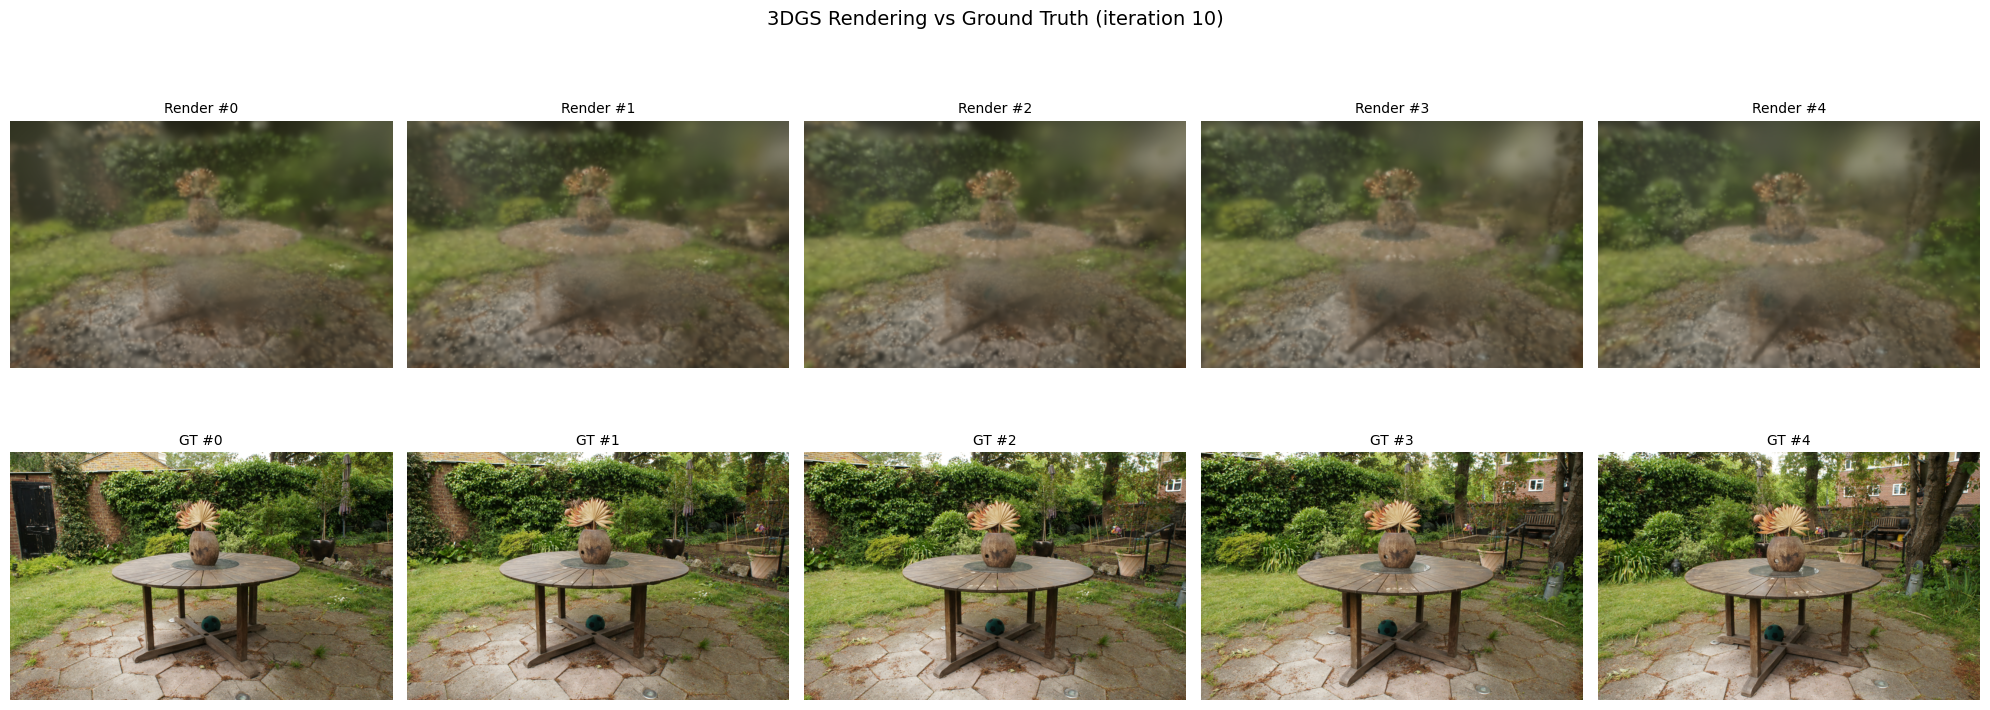

In [ ]:
# ──────────── Display rendered images vs ground truth ────────────
import glob
from PIL import Image
import matplotlib.pyplot as plt

render_dir = os.path.join(output_dir, "train", "ours_30000", "renders")
gt_dir     = os.path.join(output_dir, "train", "ours_30000", "gt")

renders = sorted(glob.glob(os.path.join(render_dir, "*.png")))
gts     = sorted(glob.glob(os.path.join(gt_dir, "*.png")))

if not renders:
    print(f"No renders found in {render_dir}. Run the render cell first.")
else:
    n_show = min(5, len(renders))
    indices = [int(i * len(renders) / n_show) for i in range(n_show)]

    fig, axes = plt.subplots(2, n_show, figsize=(4 * n_show, 8))
    if n_show == 1:
        axes = axes.reshape(2, 1)

    for col, idx in enumerate(indices):
        render_img = Image.open(renders[idx])
        gt_img     = Image.open(gts[idx])

        axes[0, col].imshow(render_img)
        axes[0, col].set_title(f"Render #{idx}", fontsize=10)
        axes[0, col].axis("off")

        axes[1, col].imshow(gt_img)
        axes[1, col].set_title(f"GT #{idx}", fontsize=10)
        axes[1, col].axis("off")

    axes[0, 0].set_ylabel("Rendered", fontsize=12)
    axes[1, 0].set_ylabel("Ground Truth", fontsize=12)
    plt.suptitle("3DGS Rendering vs Ground Truth (iteration 30000)", fontsize=14)
    plt.tight_layout()
    plt.show()

    print(f"Total rendered views: {len(renders)}")


In [2]:
import numpy as np

# Sample 3D array with shape (2, 3, 4):
# 2 layers
# 3 rows per layer
# 4 columns per row

n = np.array([
    [
        [1, 2, 3, 4],
        [5, 6, 7, 8],
        [9, 10, 11, 12]
    ],
    [
        [13, 14, 15, 16],
        [17, 18, 19, 20],
        [21, 22, 23, 24]
    ]
])

In [6]:
n[:, 0, 1]


array([ 2, 14])